# **IMPORT LIBRARIES**

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from scipy.stats import skew, kurtosis
import scipy.stats as stats
import numpy as np
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
from scipy.stats import pearsonr, chi2_contingency, ttest_ind
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# **LOAD DATASET**

In [8]:
df=pd.read_csv("/content/Food_Delivery_Times.csv")

# **BASIC DATASET INSPECTION**

In [9]:
df.shape

(1000, 9)

In [10]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [11]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [12]:
#to know about the data : it includes all the entries basically(meta data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [13]:
#to see the destribution of my dataset , a basic statistics of my dataset of every column
df.describe(include='all')

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970,970,970,1000,1000.000000,970.000000,1000.000000
unique,NaN,NaN,5,3,4,3,NaN,NaN,NaN
top,NaN,NaN,Clear,Medium,Morning,Bike,NaN,NaN,NaN
freq,NaN,NaN,470,390,308,503,NaN,NaN,NaN
mean,500.500000,10.059970,NaN,NaN,NaN,NaN,16.982000,4.579381,56.732000
std,288.819436,5.696656,NaN,NaN,NaN,NaN,7.204553,2.914394,22.070915
min,1.000000,0.590000,NaN,NaN,NaN,NaN,5.000000,0.000000,8.000000
25%,250.750000,5.105000,NaN,NaN,NaN,NaN,11.000000,2.000000,41.000000
50%,500.500000,10.190000,NaN,NaN,NaN,NaN,17.000000,5.000000,55.500000
75%,750.250000,15.017500,NaN,NaN,NaN,NaN,23.000000,7.000000,71.000000


# **Data Cleaning & Missing Values**

In [14]:
#to see hoe manu null values are there in the dataset:
df.isnull()#it only gives me true and false values
df.isnull().sum()#it counts the true and false values accordingly

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


# **Categorical Variables & Unique Values**

In [15]:
df['Weather'].unique()

array(['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', nan], dtype=object)

In [16]:
df['Traffic_Level'].unique()

array(['Low', 'Medium', 'High', nan], dtype=object)

In [17]:
df['Time_of_Day'].unique()

array(['Afternoon', 'Evening', 'Night', 'Morning', nan], dtype=object)

In [18]:
df['Vehicle_Type'].unique()

array(['Scooter', 'Bike', 'Car'], dtype=object)

In [19]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

# **Univariate Analysis**

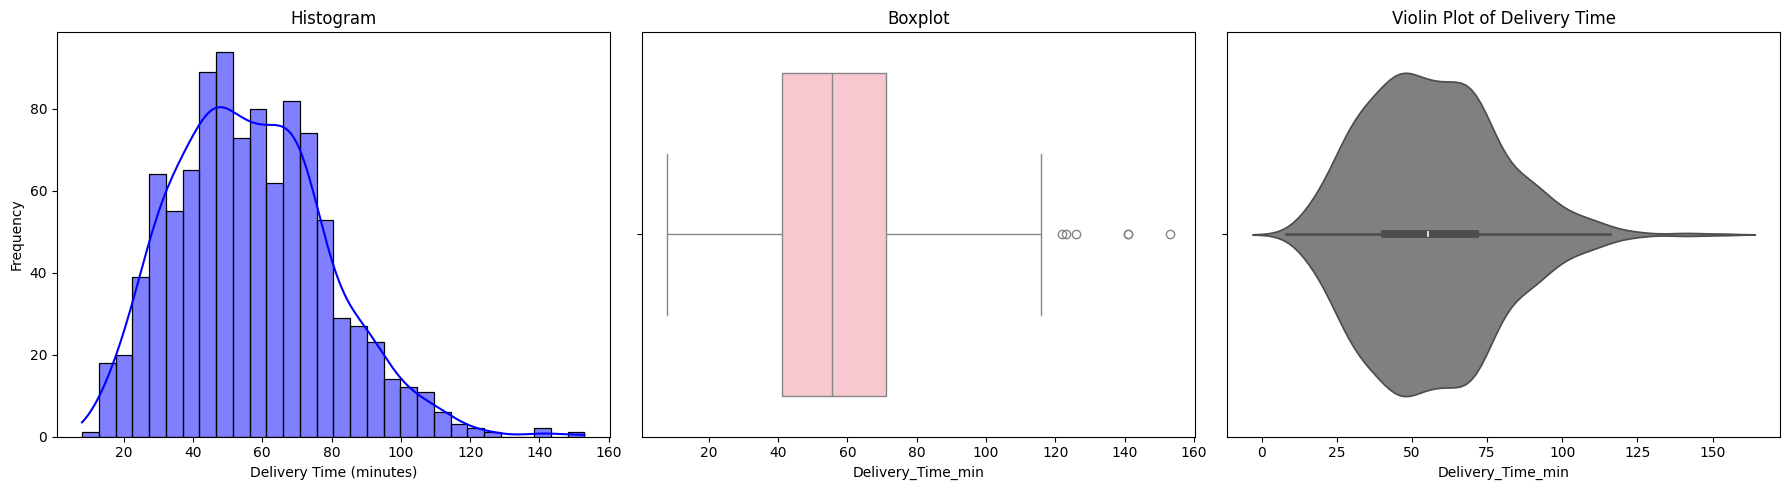

In [20]:
# Univariate Analysis - Initial Visualization
plt.figure(figsize=(18,5))
# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df["Delivery_Time_min"], bins=30, kde=True, color="blue")
plt.title("Histogram")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

# Box plot
plt.subplot(1, 3, 2)
sns.boxplot(x=df["Delivery_Time_min"], color="pink")
plt.title("Boxplot")

# Violin plot
plt.subplot(1, 3, 3)
sns.violinplot(x=df["Delivery_Time_min"], color="grey")
plt.title("Violin Plot of Delivery Time")

plt.tight_layout()
plt.show()

# **Outlier Detection & Removal**

In [21]:
# Detect Outliers using Z-score Method
z_scores = stats.zscore(df["Delivery_Time_min"])
threshold = 3  # Common threshold for outliers
outliers_z = df[abs(z_scores) > threshold]
print(f"Number of outliers detected by Z-score: {len(outliers_z)}")

Number of outliers detected by Z-score: 5


In [22]:
# Removing Outliers using Z-score method
df_cleaned_z = df[abs(z_scores) <= threshold]

In [23]:
# Display dataset size before and after outlier removal (Z-score)
print(f"Original dataset size: {df.shape[0]}")
print(f"Cleaned dataset size using Z-score: {df_cleaned_z.shape[0]}")

Original dataset size: 1000
Cleaned dataset size using Z-score: 995


In [24]:
# Detect Outliers using IQR Method
Q1 = df["Delivery_Time_min"].quantile(0.25)
Q3 = df["Delivery_Time_min"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df["Delivery_Time_min"] < lower_bound) | (df["Delivery_Time_min"] > upper_bound)]
print(f"Number of outliers detected by IQR: {len(outliers_iqr)}")

Number of outliers detected by IQR: 6


In [25]:
# Removing Outliers using IQR method
df_cleaned = df[(df["Delivery_Time_min"] >= lower_bound) & (df["Delivery_Time_min"] <= upper_bound)]

In [26]:
# Display dataset size before and after outlier removal(IOR method)
print(f"Original dataset size: {df.shape[0]}")
print(f"Cleaned dataset size: {df_cleaned.shape[0]}")

Original dataset size: 1000
Cleaned dataset size: 994


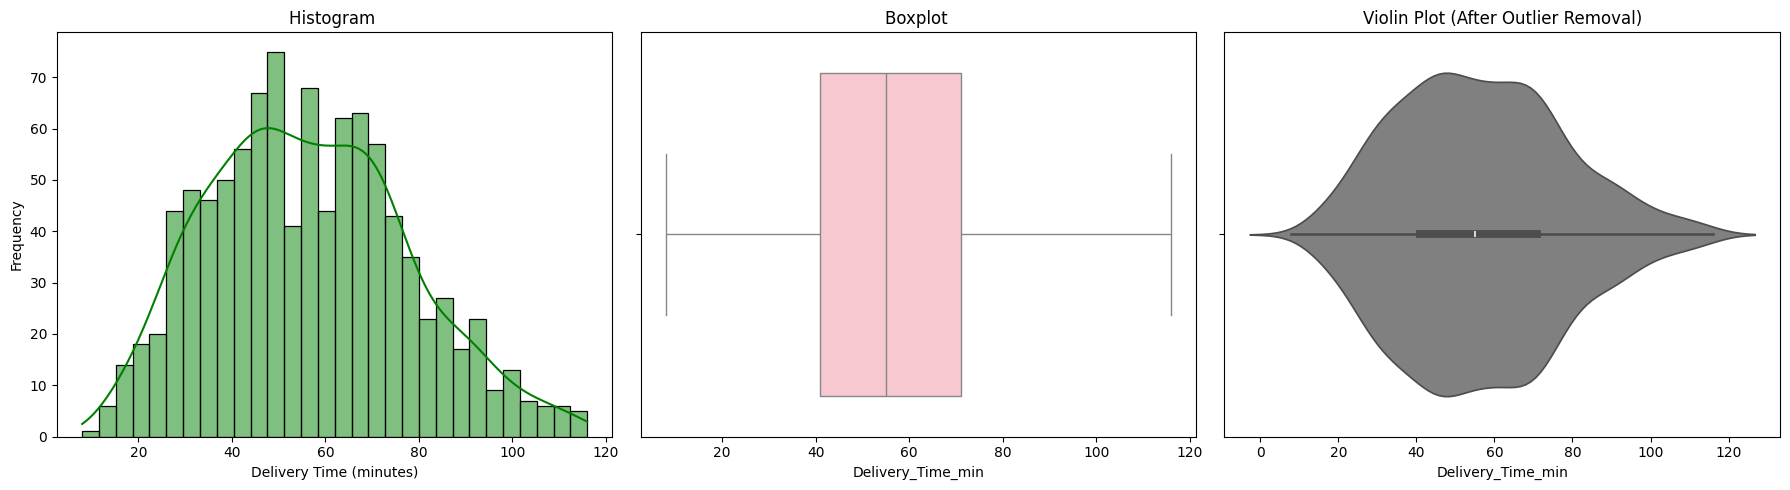

In [27]:
# Visualization After Outlier Removal (IQR method)
plt.figure(figsize=(18, 5))
# Histogram after outlier removal
plt.subplot(1, 3, 1)
sns.histplot(df_cleaned["Delivery_Time_min"], bins=30, kde=True, color="green")
plt.title("Histogram ")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

# Box plot after outlier removal
plt.subplot(1, 3, 2)
sns.boxplot(x=df_cleaned["Delivery_Time_min"], color="pink")
plt.title("Boxplot ")

# Violin plot after outlier removal
plt.subplot(1, 3, 3)
sns.violinplot(x=df_cleaned["Delivery_Time_min"], color="grey")
plt.title("Violin Plot (After Outlier Removal)")

plt.tight_layout()
plt.show()


# **Skewness, Kurtosis & Distribution Analysis**

In [28]:
print(f"Skewness: {skew(df_cleaned['Delivery_Time_min'])}")
print(f"Kurtosis: {kurtosis(df_cleaned['Delivery_Time_min'])}")

Skewness: 0.3220774659711416
Kurtosis: -0.3647688027705125


<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

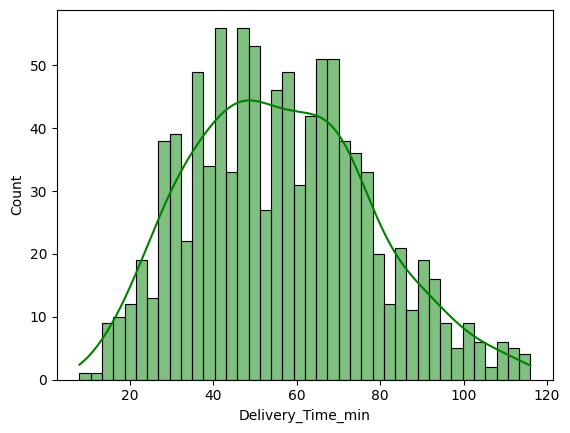

In [29]:
# Plot Histogram with Kernel Density Estimate (KDE)
sns.histplot(df_cleaned["Delivery_Time_min"], bins=40, kde=True, kde_kws={'bw_adjust': 1.2}, color="green")
#kde_kws={'bw_adjust': 1.2} → Adjusts the KDE bandwidth for a smoother density curve.

In [30]:
# Compute the mean and standard deviation for Normal Distribution Fit
mu, sigma = df_cleaned["Delivery_Time_min"].mean(), df_cleaned["Delivery_Time_min"].std()
# Generate an array of 100 equally spaced points between min and max values of delivery time
x = np.linspace(df_cleaned["Delivery_Time_min"].min(), df_cleaned["Delivery_Time_min"].max(), 100)
# Calculate the probability density function (PDF) for the normal distribution
y = stats.norm.pdf(x, mu, sigma)

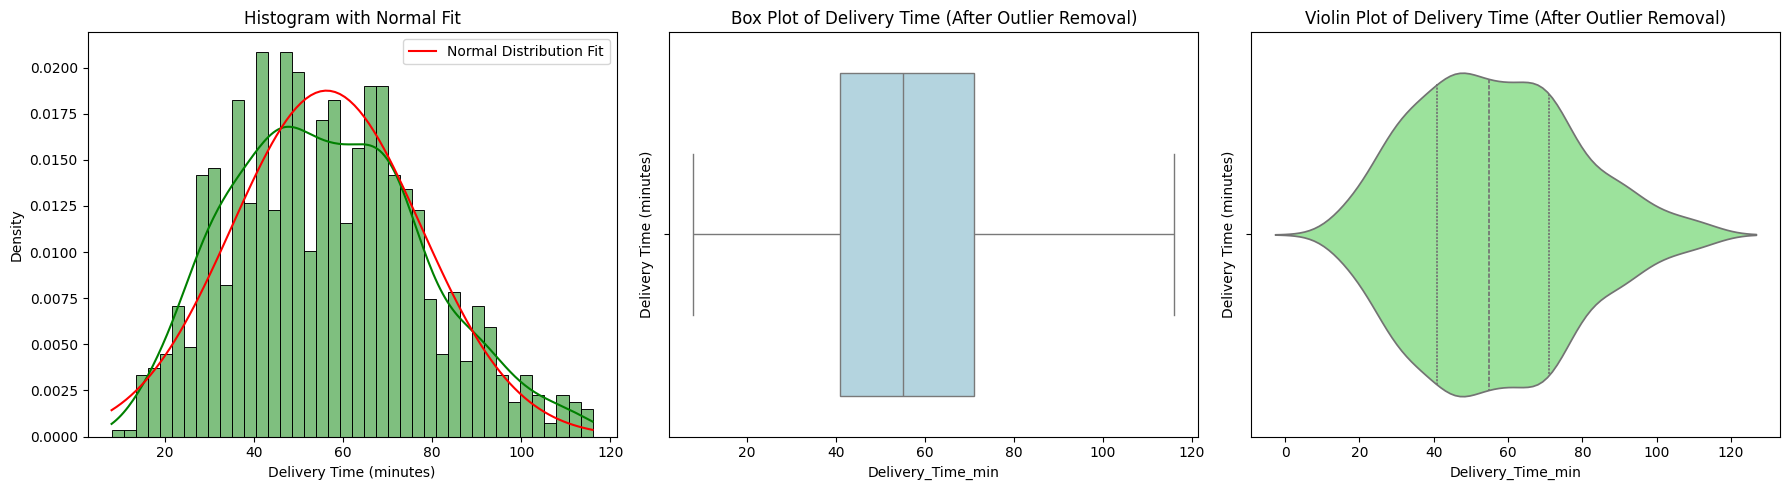

In [31]:
# Create a figure with a specific size
plt.figure(figsize=(18, 5))
# Create the first subplot for Histogram
plt.subplot(1, 3, 1)# 1 row, 3 columns, first plot

sns.histplot(df_cleaned["Delivery_Time_min"], bins=40, kde=True, color="green", stat="density")# Histogram with density
plt.plot(x, y, 'r-', label="Normal Distribution Fit")# Plot normal distribution curve in red
plt.legend()
plt.title("Histogram with Normal Fit")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Density")

# Create the second subplot for Box Plot
plt.subplot(1, 3, 2)# 1 row, 3 columns, second plot
sns.boxplot(x=df_cleaned["Delivery_Time_min"], color="lightblue")# Box plot for Delivery Time
plt.title("Box Plot of Delivery Time (After Outlier Removal)")
plt.ylabel("Delivery Time (minutes)")

# Create the third subplot for Violin Plot
plt.subplot(1, 3, 3)  # 1 row, 3 columns, third plot
sns.violinplot(x=df_cleaned["Delivery_Time_min"], color="lightgreen", inner="quartile") # Violin plot for density
plt.title("Violin Plot of Delivery Time (After Outlier Removal)")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()

# **Numeric Feature Analysis**

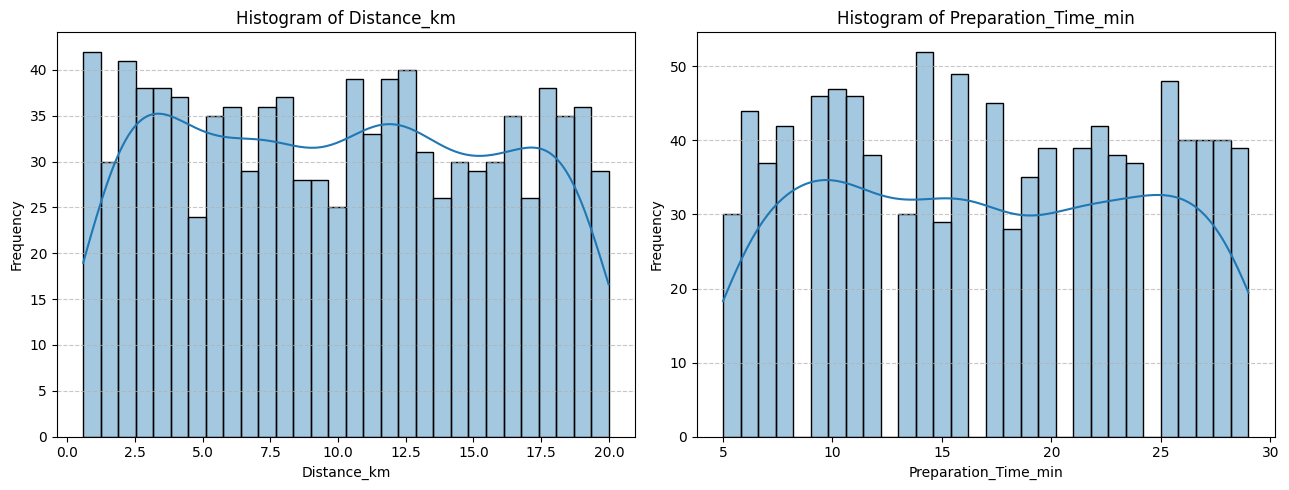

In [32]:
# Define numeric columns
numeric_columns = ["Distance_km", "Preparation_Time_min"]

# Create a figure with subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(13, 5))

# Loop through each column and create a histogram in the corresponding subplot
for i, column in enumerate(numeric_columns):
    sns.histplot(df[column].dropna(), bins=30, kde=True, edgecolor='black', alpha=0.4, ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

In [33]:
cols = ["Distance_km", "Preparation_Time_min"]
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    rows_removed = len(df) - len(df_cleaned)
    print(f"Removed {rows_removed} outliers from '{col}'.")
    print(f"New dataset shape: {df_cleaned.shape}")

Removed 0 outliers from 'Distance_km'.
New dataset shape: (1000, 9)
Removed 0 outliers from 'Preparation_Time_min'.
New dataset shape: (1000, 9)


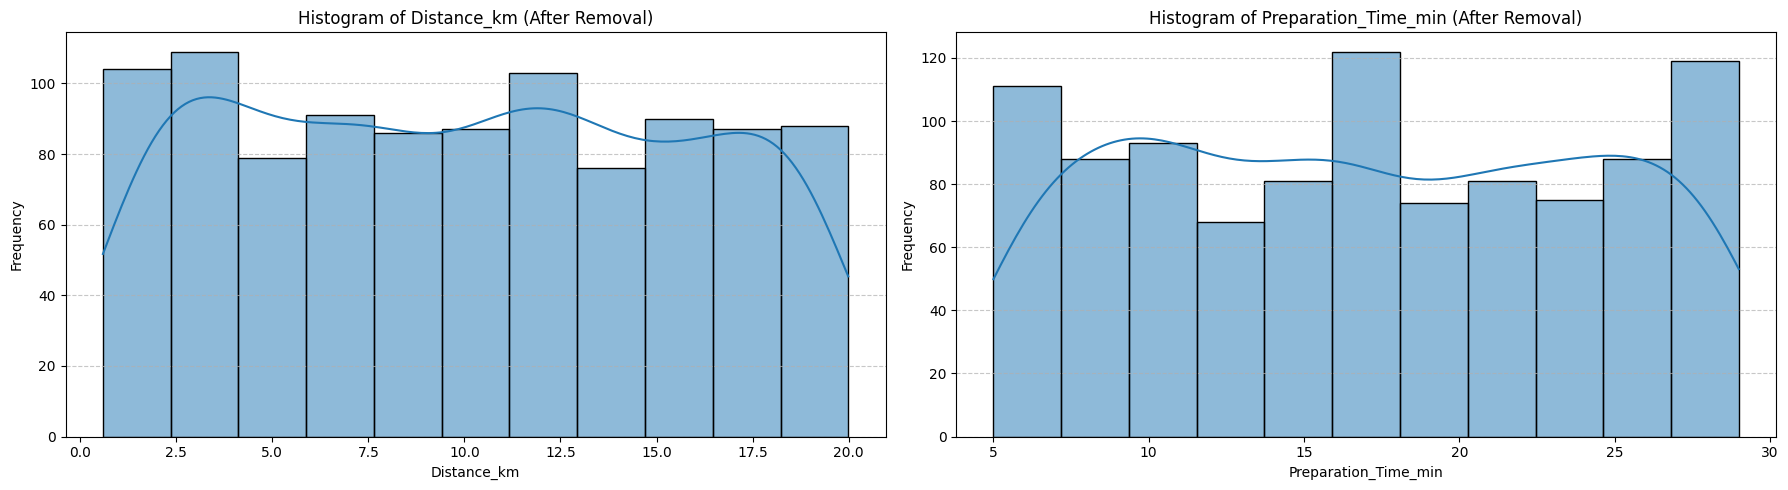

In [34]:
numeric_columns = ["Distance_km", "Preparation_Time_min"]

fig, axes = plt.subplots(1, len(numeric_columns), figsize=(18, 5))
for i, column in enumerate(numeric_columns):
    sns.histplot(df_cleaned[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {column} (After Removal)')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

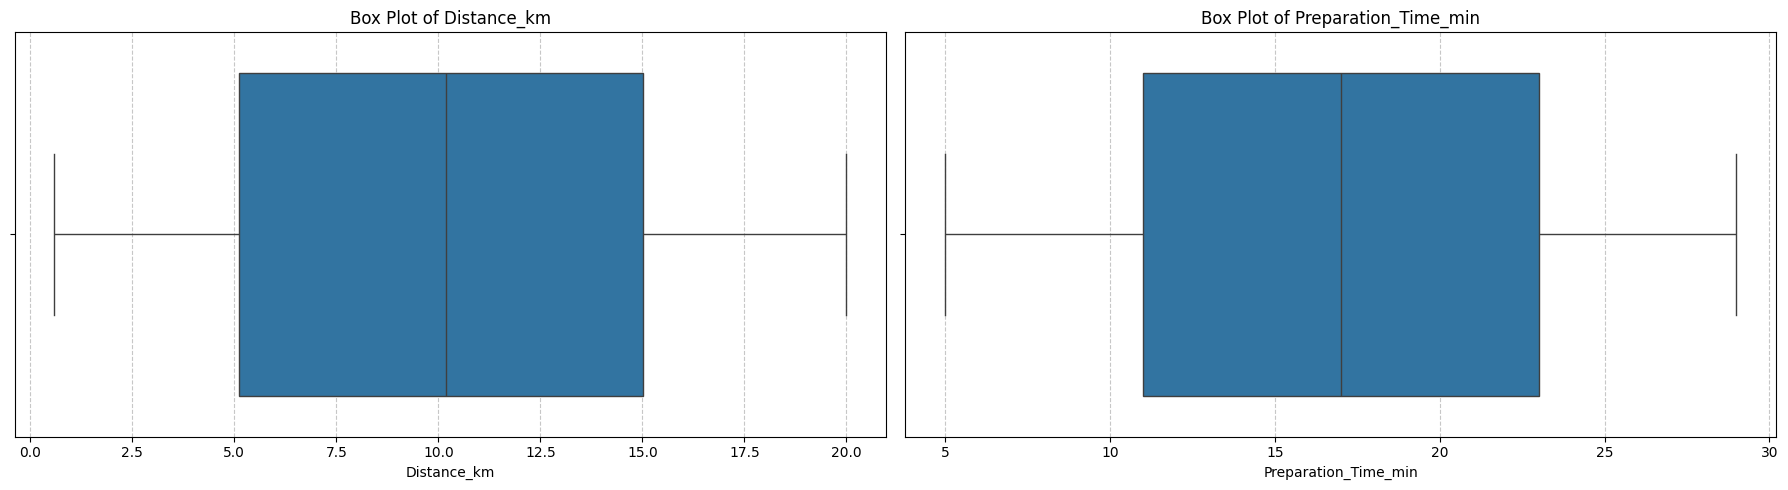

In [35]:
numeric_columns = ["Distance_km", "Preparation_Time_min"]
# Create a figure with subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(18, 5))
# Loop through each column and create a box plot in the corresponding subplot
for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df_cleaned[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_xlabel(column)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

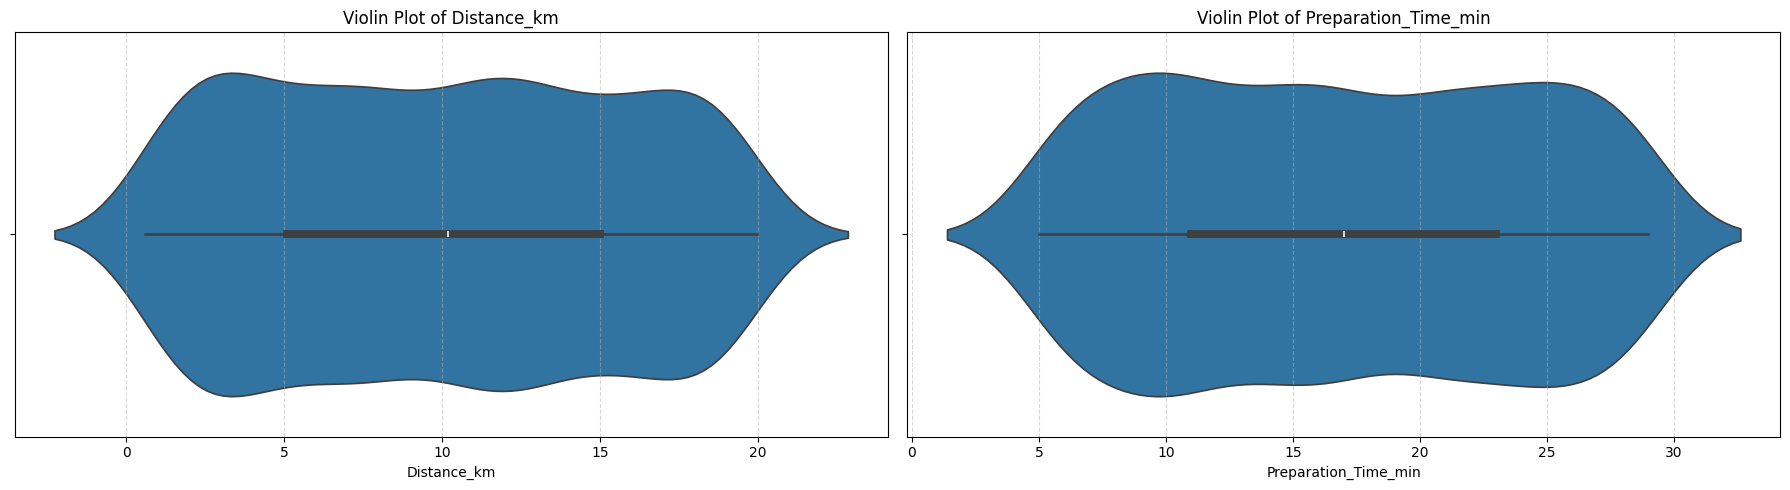

In [36]:
numeric_columns = ["Distance_km", "Preparation_Time_min"]
# Create a figure with subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(18, 5))
# Loop through each column and create a violin plot in the corresponding subplot
for i, column in enumerate(numeric_columns):
    sns.violinplot(x=df_cleaned[column], ax=axes[i])
    axes[i].set_title(f'Violin Plot of {column}')
    axes[i].set_xlabel(column)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

# **Bivariate Analysis**

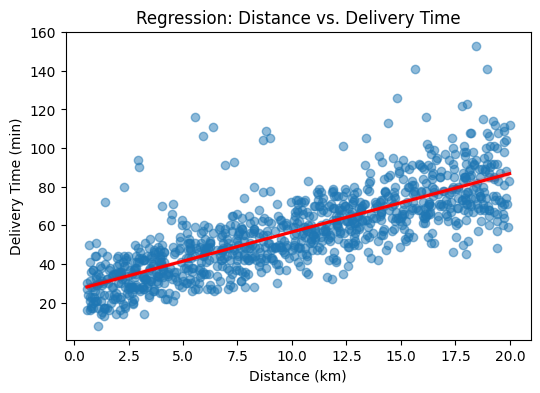

In [37]:
#bivariate analysis
#1- Regression analysis on distance and delivery time :
# Scatter Plot with Regression Line
plt.figure(figsize=(6, 4))
sns.regplot(x="Distance_km", y="Delivery_Time_min", data=df, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Regression: Distance vs. Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

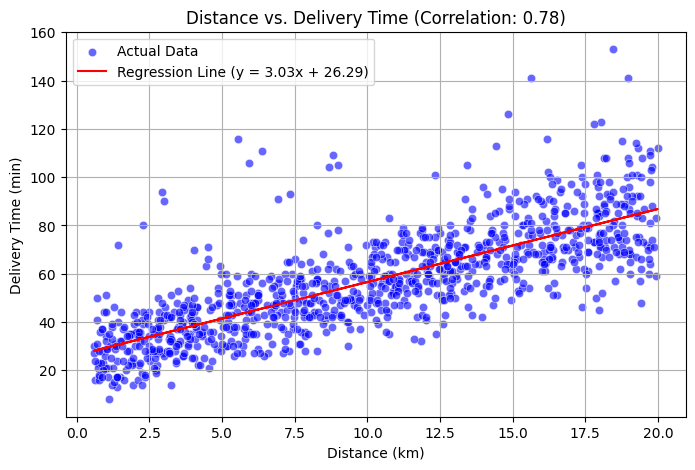

In [40]:
# Pearson Correlation
corr_value, p_value = pearsonr(df["Distance_km"], df["Delivery_Time_min"])

# Regression Analysis
X = df["Distance_km"]
y = df["Delivery_Time_min"]
m, b = np.polyfit(X, y, 1)  # Compute slope (m) and intercept (b)

# Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X, y=y, alpha=0.6, label="Actual Data", color="blue")
plt.plot(X, m * X + b, color="red", label=f"Regression Line (y = {m:.2f}x + {b:.2f})")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title(f"Distance vs. Delivery Time (Correlation: {corr_value:.2f})")
plt.legend()
plt.grid(True)
plt.show()

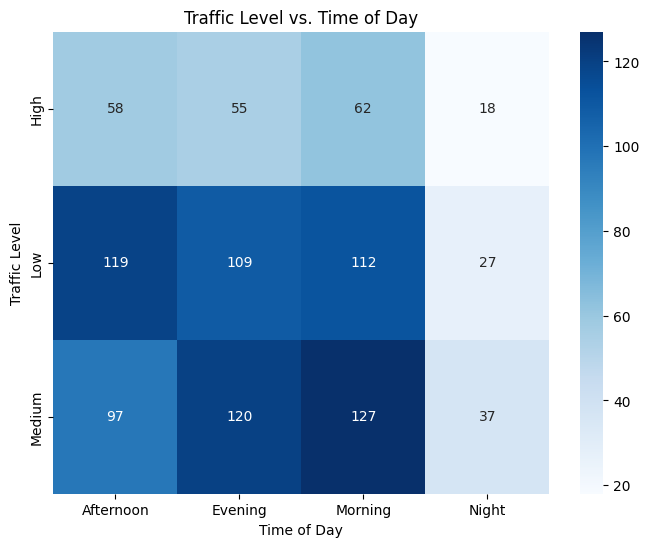

Chi-Square Statistic: 5.37, p-value: 0.49685


In [41]:
# Creating contingency table
contingency_table = pd.crosstab(df["Traffic_Level"], df["Time_of_Day"])

# Perform Chi-Square Test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# Chi-Square Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d")
plt.title("Traffic Level vs. Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Traffic Level")
plt.show()

print(f"Chi-Square Statistic: {chi2_stat:.2f}, p-value: {p_val:.5f}")

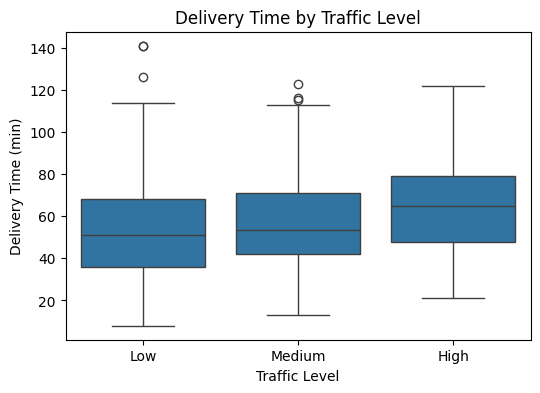

T-Statistic: -6.24, p-value: 0.00000


In [42]:
# Filtering Delivery Time for different Traffic Levels
low_traffic_time = df[df["Traffic_Level"] == "Low"]["Delivery_Time_min"]
high_traffic_time = df[df["Traffic_Level"] == "High"]["Delivery_Time_min"]

# Perform T-Test
t_stat, p_value_ttest = ttest_ind(low_traffic_time, high_traffic_time, equal_var=False)

# Box Plot for Traffic Level vs. Delivery Time
plt.figure(figsize=(6, 4))
sns.boxplot(x="Traffic_Level", y="Delivery_Time_min", data=df)
plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (min)")
plt.show()

print(f"T-Statistic: {t_stat:.2f}, p-value: {p_value_ttest:.5f}")

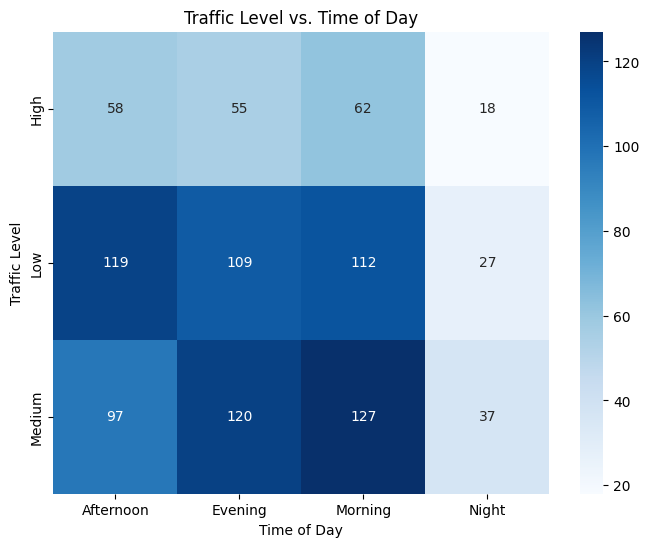

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df["Traffic_Level"], df["Time_of_Day"]), annot=True, cmap="Blues", fmt="d")
plt.title("Traffic Level vs. Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Traffic Level")
plt.show()

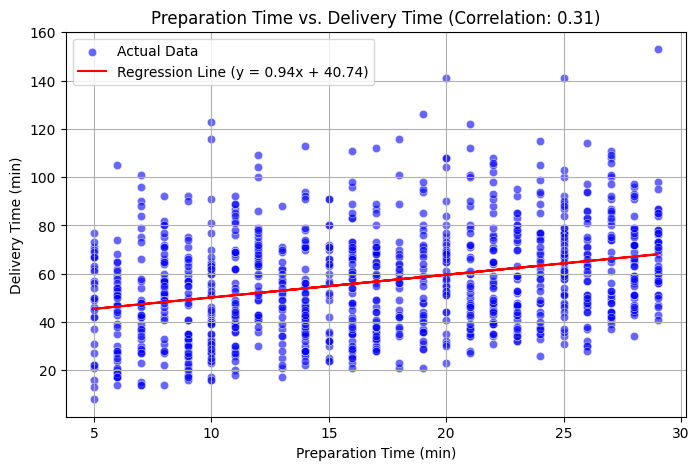

Regression Equation: Delivery_Time = 0.94 * Preparation_Time + 40.74
Pearson Correlation: 0.31, p-value: 0.00000


In [44]:
#1- Regression analysis on Preparation time and delivery time :
# Pearson Correlation
corr_value, p_value = pearsonr(df["Preparation_Time_min"], df["Delivery_Time_min"])

# Regression Analysis
X = df["Preparation_Time_min"]
y = df["Delivery_Time_min"]
m, b = np.polyfit(X, y, 1)  # Compute slope (m) and intercept (b)

# Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X, y=y, alpha=0.6, label="Actual Data", color="blue")
plt.plot(X, m * X + b, color="red", label=f"Regression Line (y = {m:.2f}x + {b:.2f})")
plt.xlabel("Preparation Time (min)")
plt.ylabel("Delivery Time (min)")
plt.title(f"Preparation Time vs. Delivery Time (Correlation: {corr_value:.2f})")
plt.legend()
plt.grid(True)
plt.show()

# Print results
# Regression Equation:
print(f"Regression Equation: Delivery_Time = {m:.2f} * Preparation_Time + {b:.2f}")
# A 1-minute increase in preparation time leads to an increase of 0.94 minutes in delivery time.
# The intercept (40.74) suggests a base delivery time of ~41 minutes when preparation time is 0.
print(f"Pearson Correlation: {corr_value:.2f}, p-value: {p_value:.5f}")
# Correlation (0.31) → Weak positive correlation.
# This suggests that while preparation time does impact delivery time, it’s not the strongest factor.
#Other factors (e.g., traffic, weather) might be more influential.
# p-value (0.00000) < 0.05 → The relationship is statistically significant.


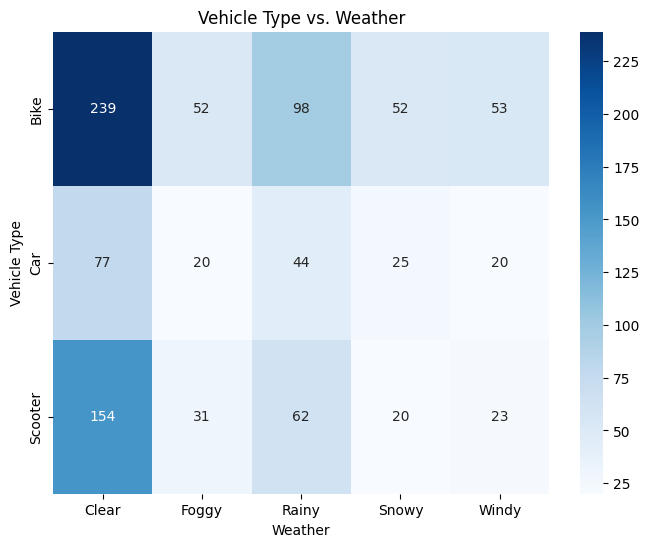

Chi-Square Statistic: 10.92, p-value: 0.20615


In [45]:
# Create contingency table
contingency_table = pd.crosstab(df["Vehicle_Type"], df["Weather"])

# Perform Chi-Square Test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# Chi-Square Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d")
plt.title("Vehicle Type vs. Weather")
plt.xlabel("Weather")
plt.ylabel("Vehicle Type")
plt.show()

print(f"Chi-Square Statistic: {chi2_stat:.2f}, p-value: {p_val:.5f}")
# p-value (0.20615) > 0.05 → No significant relationship between Vehicle Type and Weather.
# This suggests that vehicles (e.g., bike, scooter, car) are used almost equally in all weather conditions.
# Chi-square statistic (10.92) shows some variation, but it's not strong enough to be statistically significant.

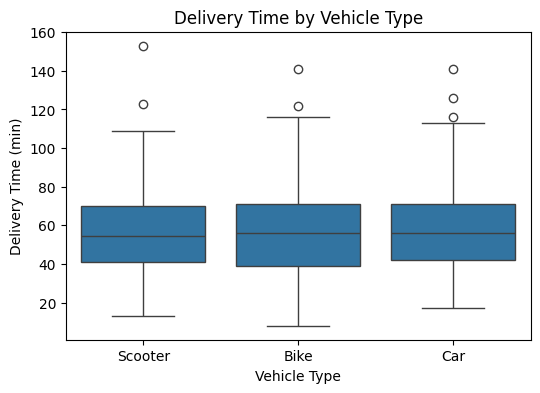

T-Statistic: 0.33, p-value: 0.73966


In [46]:
# Filtering Delivery Time for different Vehicle Types
bike_time = df_cleaned[df["Vehicle_Type"] == "Bike"]["Delivery_Time_min"]
scooter_time = df_cleaned[df["Vehicle_Type"] == "Scooter"]["Delivery_Time_min"]

# Perform T-Test
t_stat, p_value_ttest = ttest_ind(bike_time, scooter_time, equal_var=False)

# Box Plot for Vehicle Type vs. Delivery Time
plt.figure(figsize=(6, 4))
sns.boxplot(x="Vehicle_Type", y="Delivery_Time_min", data=df)
plt.title("Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (min)")
plt.show()

print(f"T-Statistic: {t_stat:.2f}, p-value: {p_value_ttest:.5f}")
# p-value (0.73966) > 0.05 → No significant difference in delivery time between different vehicle types.
# T-statistic (0.33) is very small, meaning the difference is negligible.
# Conclusion:
# Whether the delivery is made by a bike, scooter, or car, the delivery time remains about the same.

# **Categorical Encoding**

In [47]:
df = pd.get_dummies(df, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True)

df.head

<bound method NDFrame.head of      Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         522         7.93                    12                     1.0   
1         738        16.42                    20                     2.0   
2         741         9.52                    28                     1.0   
3         661         7.44                     5                     1.0   
4         412        19.03                    16                     5.0   
..        ...          ...                   ...                     ...   
995       107         8.50                    13                     3.0   
996       271        16.28                     8                     9.0   
997       861        15.62                    26                     2.0   
998       436        14.17                     8                     0.0   
999       103         6.63                    24                     3.0   

     Delivery_Time_min  Weather_Foggy  Weather_Rainy  Weather_Snowy  \
0                   43          False          False          False   
1                   84          False          False          False   
2                   59           True          False          False   
3                   37          False           True          False   
4                   68          False          False          False   
..                 ...            ...            ...            ...   
995                 54          False          False          False   
996                 71          False           True          False   
997                 81          False          False           True   
998                 55          False          False          False   
999                 58           True          False          False   

     Weather_Windy  Traffic_Level_Low  Traffic_Level_Medium  \
0             True               True                 False   
1            False              False                  True   
2            False               True                 False   
3            False              False                  True   
4            False               True                 False   
..             ...                ...                   ...   
995          False              False                 False   
996          False               True                 False   
997          False              False                 False   
998          False               True                 False   
999          False               True                 False   

     Time_of_Day_Evening  Time_of_Day_Morning  Time_of_Day_Night  \
0                  False                False              False   
1                   True                False              False   
2                  False                False               True   
3                  False                False              False   
4                  False                 True              False   
..                   ...                  ...                ...   
995                 True                False              False   
996                False                 True              False   
997                 True                False              False   
998                False                False              False   
999                False                False               True   

     Vehicle_Type_Car  Vehicle_Type_Scooter  
0               False                  True  
1               False                 False  
2               False                  True  
3               False                  True  
4               False                 False  
..                ...                   ...  
995              True                 False  
996             False                  True  
997             False                  True  
998             False                 False  
999             False                  True  

[1000 rows x 16 columns]>

In [48]:
bool_cols = df.select_dtypes(include=['bool']).columns  # Identify boolean columns
df[bool_cols] = df[bool_cols].astype(int)  # Convert to 0/1



In [49]:
print(df.head())  # Verify data format
print(df.dtypes)

   Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0       522         7.93                    12                     1.0   
1       738        16.42                    20                     2.0   
2       741         9.52                    28                     1.0   
3       661         7.44                     5                     1.0   
4       412        19.03                    16                     5.0   

   Delivery_Time_min  Weather_Foggy  Weather_Rainy  Weather_Snowy  \
0                 43              0              0              0   
1                 84              0              0              0   
2                 59              1              0              0   
3                 37              0              1              0   
4                 68              0              0              0   

   Weather_Windy  Traffic_Level_Low  Traffic_Level_Medium  \
0              1                  1                     0   
1              0  

# **Feature Scaling**

In [50]:
scaler = MinMaxScaler()
df[['Distance_km', 'Preparation_Time_min']] = scaler.fit_transform(df[['Distance_km', 'Preparation_Time_min']])

In [51]:
print(df.head())  # Check if values are between 0 and 1
print(df.describe())  # Ensure the min is 0 and max is 1

   Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0       522     0.378351              0.291667                     1.0   
1       738     0.815979              0.625000                     2.0   
2       741     0.460309              0.958333                     1.0   
3       661     0.353093              0.000000                     1.0   
4       412     0.950515              0.458333                     5.0   

   Delivery_Time_min  Weather_Foggy  Weather_Rainy  Weather_Snowy  \
0                 43              0              0              0   
1                 84              0              0              0   
2                 59              1              0              0   
3                 37              0              1              0   
4                 68              0              0              0   

   Weather_Windy  Traffic_Level_Low  Traffic_Level_Medium  \
0              1                  1                     0   
1              0  

# **Defining Features and Target**

In [52]:
# Define independent variables (X) and dependent variable (y)
X = df[['Distance_km', 'Preparation_Time_min',
        'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
        'Traffic_Level_Low', 'Traffic_Level_Medium',
        'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
        'Vehicle_Type_Car', 'Vehicle_Type_Scooter']]  # Independent variables

y = df['Delivery_Time_min']  # Dependent variable (Target)

# **Train-Test Split**

In [53]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Check shapes of training and testing sets
print("X_train shape:", X_train.shape)  # Features in training set
print("X_test shape:", X_test.shape)    # Features in testing set
print("y_train shape:", y_train.shape)  # Target values in training set
print("y_test shape:", y_test.shape)    # Target values in testing set

X_train shape: (800, 13)
X_test shape: (200, 13)
y_train shape: (800,)
y_test shape: (200,)


# **Binary Classification Setup**

In [55]:

# Convert Delivery Time into Binary Classification
median_delivery_time = y_train.median()
y_train_class = np.where(y_train > median_delivery_time, 1, 0)
y_test_class = np.where(y_test > median_delivery_time, 1, 0)

# **Logistic Regression**

In [56]:
#Lgistic Regression algorithm
# Initialize the model
log_reg = LogisticRegression()

# Train the model on training data
log_reg.fit(X_train, y_train_class)

# Predict on test data
y_pred = log_reg.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test_class, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.93
